<a href="https://colab.research.google.com/github/HUGOBROWNING/google-stock-quant-forecasting/blob/main/Google_Analysis_Part_1_(GBM_%26_MonteCarlo).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import os
import pandas as pd
import yfinance as yf

ticker='GOOGL'
start='2010-06-01'
end = '2026-06-01'

raw =yf.download(
    ticker,
    start = start,
    end = end
)

if isinstance(raw.columns, pd.MultiIndex):
  raw.columns=raw.columns.get_level_values(0)

raw = raw.sort_index()
raw = raw[raw['Volume'] > 0].dropna(
    subset = [
        'Close'
    ]
)
raw.head()

/tmp/ipykernel_12317/834280377.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw =yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-06-01,11.965222,12.180779,11.909411,11.917101,106565328
2010-06-02,12.238078,12.250480,11.942650,12.072132,101530368
2010-06-03,12.541445,12.600977,12.271069,12.281239,145881972
2010-06-04,12.370784,12.631981,12.320678,12.395589,156655188
2010-06-07,12.043360,12.425109,11.984572,12.379220,145162692


In [30]:
x, y = raw.shape
print(f'Rows: {x} || Columns: {y}')

Rows: 4024 || Columns: 5


In [31]:
!pip install ydata_profiling

In [32]:
from ydata_profiling import ProfileReport
title = 'Automated Analysis of Google'
profile = ProfileReport(
    raw,
    title =title,
    explorative = True
)


<Axes: xlabel='Date'>

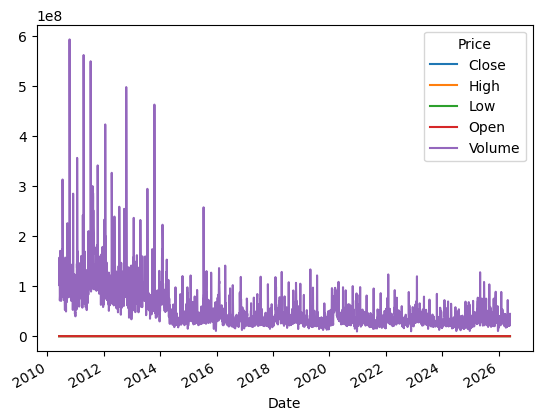

In [34]:
data=raw.copy()
data.plot()

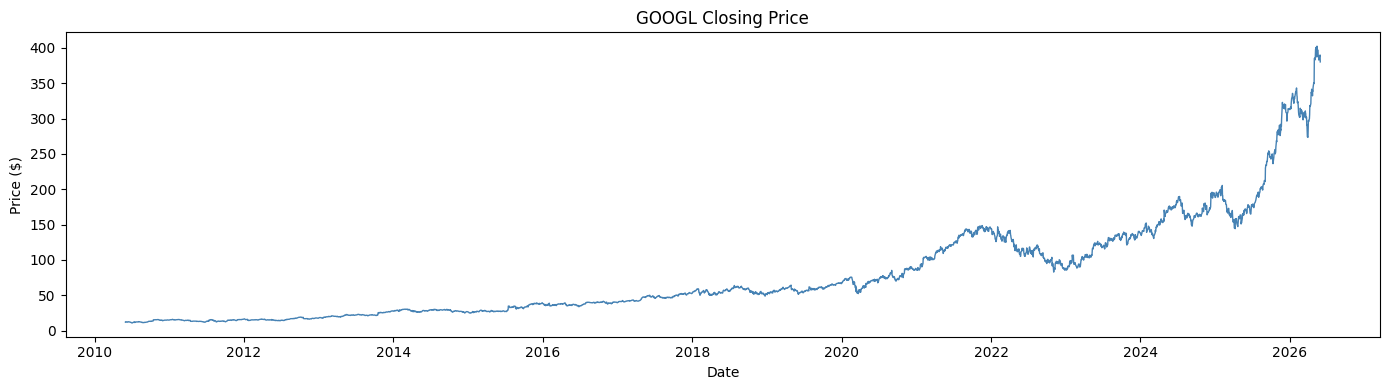

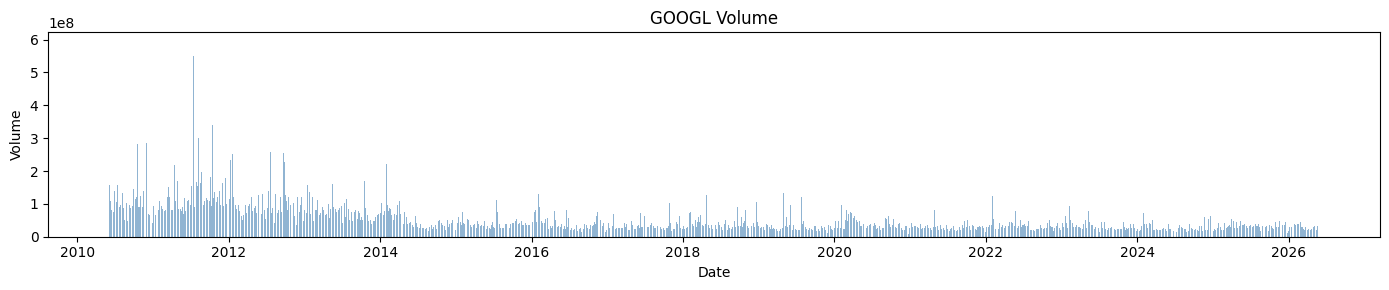

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(data['Close'], linewidth=1, color='steelblue')
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.bar(data.index, data['Volume'], width=1, color='steelblue', alpha=0.6)
plt.title(f'{ticker} Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

## Step 2: Pearson Correlation Between Features

Before modelling, we check linear relationships between raw OHLCV columns.

The Pearson correlation coefficient between two variables $x$ and $y$:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Where $r \in [-1, 1]$: values near $\pm 1$ indicate a strong linear association.

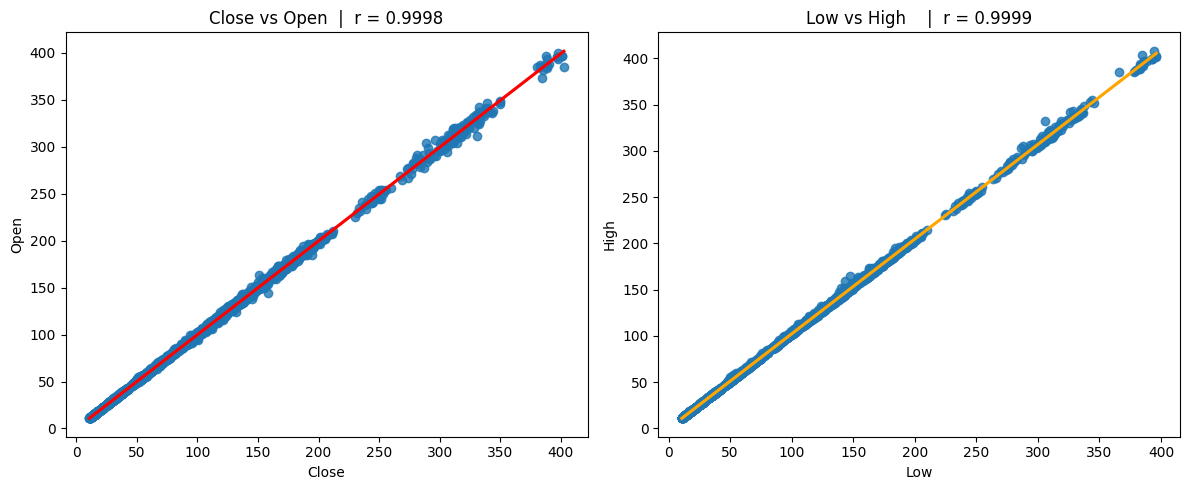

In [36]:
import seaborn as sns

def pearson_corr(df, col_x, col_y):
    x, y = df[col_x].values, df[col_y].values
    num = np.sum((x - x.mean()) * (y - y.mean()))
    den = np.sqrt(np.sum((x - x.mean())**2) * np.sum((y - y.mean())**2))
    return np.round(num / den, 4)

r_co = pearson_corr(raw, 'Close', 'Open')
r_lh = pearson_corr(raw, 'Low',   'High')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x=raw['Close'], y=raw['Open'],  line_kws={'color':'red'},    ax=axes[0])
sns.regplot(x=raw['Low'],   y=raw['High'],  line_kws={'color':'orange'}, ax=axes[1])
axes[0].set_title(f'Close vs Open  |  r = {r_co}')
axes[1].set_title(f'Low vs High    |  r = {r_lh}')
plt.tight_layout()
plt.show()


Stock prices under Geometric Brownian Motion use log returns:

$$r_t = \ln\!\left(\frac{S_t}{S_{t-1}}\right)$$

Where $S_t$ is the closing price at time $t$.

In [37]:
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))

data['std_5'] = data['log_return'].rolling(5).std()
data['std_30'] = data['log_return'].rolling(30).std()
data['std_90'] = data['log_return'].rolling(90).std()

data['Short_vol'] = np.sqrt(252) * data['std_5']
data['Mid_vol'] = np.sqrt(252) * data['std_30']
data['Long_vol']= np.sqrt(252) * data['std_90']

data['Momentum'] = data['log_return'].shift(1).rolling(20).mean()
data['Vol_ratio'] = data['Short_vol'] / data['Mid_vol']
data['Lagged_return'] = data['log_return'].shift(1)

data = data.dropna().copy()
data = data.reset_index()
display(data.head(), data.tail())

Price,Date,Close,High,Low,Open,Volume,log_return,std_5,std_30,std_90,Short_vol,Mid_vol,Long_vol,Momentum,Vol_ratio,Lagged_return
0,2010-10-07,13.146937,13.325286,13.125357,13.300729,95736168,-0.008155,0.016140,0.012996,0.017628,0.256216,0.206298,0.279831,0.006354,1.241969,-0.007235
1,2010-10-08,13.304200,13.335207,13.087653,13.215399,114253632,0.011891,0.016691,0.012808,0.017517,0.264967,0.203321,0.278075,0.005355,1.303195,-0.008155
2,2010-10-11,13.365964,13.508842,13.324540,13.357035,104946948,0.004632,0.015695,0.012624,0.017341,0.249157,0.200399,0.275283,0.005954,1.243303,0.011891
3,2010-10-12,13.429217,13.543321,13.339919,13.397715,149993856,0.004721,0.008619,0.012115,0.017278,0.136819,0.192318,0.274277,0.005546,0.711420,0.004632
4,2010-10-13,13.476596,13.580529,13.452535,13.568375,122101776,0.003522,0.007226,0.011917,0.017025,0.114710,0.189172,0.270259,0.005973,0.606380,0.004721


Price,Date,Close,High,Low,Open,Volume,log_return,std_5,std_30,std_90,Short_vol,Mid_vol,Long_vol,Momentum,Vol_ratio,Lagged_return
3929,2026-05-22,382.741394,388.507939,381.542098,387.118784,20442100,-0.012172,0.010928,0.022953,0.019642,0.173477,0.364366,0.311809,0.006723,0.476106,-0.003219
3930,2026-05-26,388.647858,389.027636,382.371608,384.280471,27747400,0.015314,0.014823,0.022983,0.019695,0.235306,0.364838,0.312651,0.005308,0.644960,-0.012172
3931,2026-05-27,388.597870,393.644874,385.669626,386.439186,23087300,-0.000129,0.010020,0.022338,0.019663,0.159064,0.354606,0.312133,0.005218,0.448565,0.015314
3932,2026-05-28,389.897125,391.636077,384.930091,387.768392,24357500,0.003338,0.010028,0.022296,0.019634,0.159189,0.353943,0.311673,0.005292,0.449759,-0.000129
3933,2026-05-29,380.112946,385.010014,378.234063,385.010014,44415800,-0.025414,0.015549,0.022933,0.019647,0.246829,0.364042,0.311886,0.005436,0.678022,0.003338


The Geometric Brownian Motion stochastic differential equation (SDE) is:

$$dS = \mu S \, dt + \sigma S \, dW_t$$

Where:
- $\mu$ = drift (annualised expected return)
- $\sigma$ = volatility (annualised standard deviation)
- $dW_t$ = Wiener process increment, $dW_t \sim \mathcal{N}(0, dt)$

Applying **Itô's Lemma** to $f(S) = \ln(S)$ gives the closed-form solution:

$$\ln\!\left(\frac{S_t}{S_0}\right) = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t$$

We estimate $\hat{\mu}$ and $\hat{\sigma}$ from daily log returns,
then annualise using $\Delta t = \frac{1}{252}$ (one trading day as a fraction of a year):

$$\hat{\mu} = \frac{\bar{r}}{\Delta t}, \qquad \hat{\sigma} = \frac{\mathrm{std}(r)}{\sqrt{\Delta t}}$$

Using the GBM parameters estimated from training data, we simulate 1,000 future price paths.

The closed-form GBM solution at each discrete step:

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right], \quad Z \sim \mathcal{N}(0,1)$$

Where:
- $\hat{\mu} = \bar{r} / \Delta t$ — annualised drift estimated from log returns
- $\hat{\sigma} = \text{std}(r) / \sqrt{\Delta t}$ — annualised volatility
- The $\left(\mu - \frac{\sigma^2}{2}\right)$ term is the **Itô correction** from Itô's Lemma

In [38]:
log_returns = data['log_return'].values
"Assuming 252 trading days a year"
dt=1/252

mu_gbm = np.mean(log_returns)/dt
sigma_gbm=np.std(log_returns) * np.sqrt(1/dt)

print(f"Annualised drift  μ : {np.round(mu_gbm*100, 4)}% per year")
print(f"Annualised vol    σ : {np.round(sigma_gbm*100, 4)}% per year")

Annualised drift  μ : 21.4983% per year
Annualised vol    σ : 27.6473% per year


In [39]:
S0=float(data['Close'].iloc[-1])
T, N, M=1, 252, 1000
dt_mc = T/N

Z=np.random.normal(0, 1, (M, N))
increments=(mu_gbm-0.5*sigma_gbm**2)*dt_mc + sigma_gbm*np.sqrt(dt_mc)*Z
pd.DataFrame(increments).head(6)

,0,1,2,3,4,5,6,7,8,9,...,242,243,244,245,246,247,248,249,250,251
0,0.016014,0.014041,0.014127,-0.037533,0.004285,0.013727,0.019257,0.021743,0.044516,0.012884,...,0.017915,-0.013058,-0.022394,-0.020473,0.033024,0.001914,-0.012567,0.022344,0.039624,0.029825
1,0.007365,0.023509,-0.018080,0.015324,-0.023177,-0.017381,0.001649,-0.007346,-0.005220,0.016613,...,-0.005818,0.003524,0.026630,0.030140,0.010029,-0.018401,-0.002687,0.025452,0.015051,0.001556
2,0.006719,0.009336,-0.026447,-0.004489,0.023671,0.019458,-0.026852,0.000398,-0.004953,-0.003697,...,0.043353,0.013665,0.015581,0.033049,0.017809,0.000540,-0.008916,0.015479,0.010779,-0.001841
3,0.024071,-0.005727,0.005420,-0.018511,-0.008653,0.023316,-0.005299,0.043512,0.002694,-0.034539,...,-0.020723,-0.000164,0.007147,-0.007483,-0.000578,-0.015842,0.000744,0.024142,-0.046945,0.004448
4,0.008697,0.024749,0.016867,-0.001097,0.004060,-0.009176,0.021116,-0.009806,-0.000171,0.006149,...,-0.027597,0.003050,-0.012162,0.014533,0.022819,0.030159,0.023779,0.010587,0.017529,-0.000889
5,-0.003093,-0.017423,0.011630,-0.010638,-0.008355,-0.006790,0.024311,0.009473,-0.000498,-0.004535,...,-0.015276,-0.019723,0.007205,-0.019427,0.044117,-0.017018,-0.003685,0.006945,-0.001706,-0.011796


(              0
 0    606.969438
 1    453.429611
 2    449.163557
 3    290.603752
 4    593.812484
 ..          ...
 995  426.095053
 996  426.020199
 997  390.444999
 998  472.337223
 999  566.891081
 
 [1000 rows x 1 columns],
 <Axes: >)

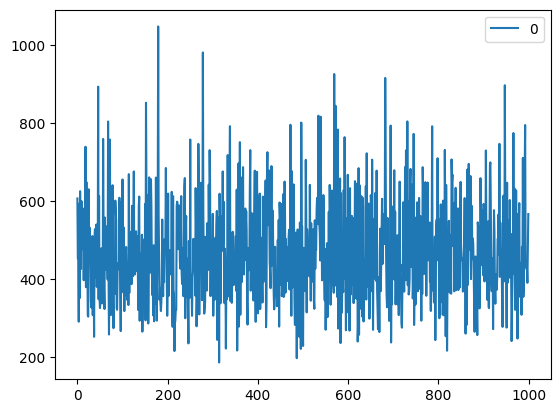

In [40]:
price_paths = S0*np.exp(np.cumsum(increments, axis=1))
final=price_paths[:, -1]

pd.DataFrame(final), pd.DataFrame(final).plot()

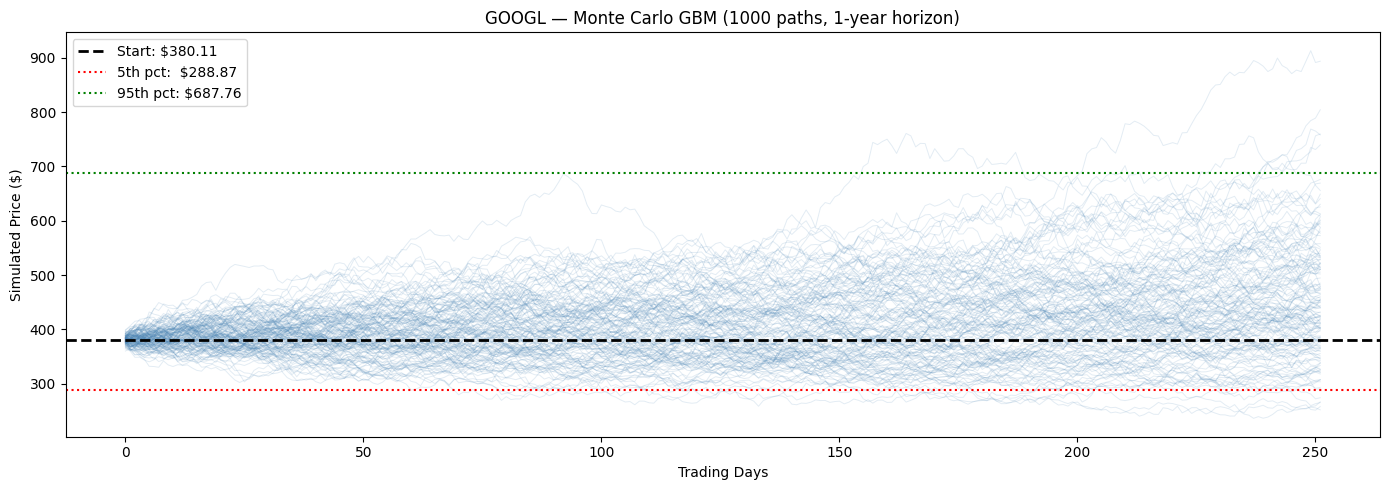

Simulation Summary (1-year horizon):
  Start price  : $380.11
  Mean price   : $468.66
  5th  pct     : $288.87
  95th pct     : $687.76
  Prob > start : 73.5%


In [41]:
plt.figure(figsize=(14, 5))
plt.plot(price_paths[:150].T, alpha=0.15, linewidth=0.7, color='steelblue')
plt.axhline(S0,                           color='black', linewidth=2,   linestyle='--', label=f'Start: ${S0:.2f}')
plt.axhline(np.percentile(final,  5),     color='red',   linewidth=1.5, linestyle=':',  label=f'5th pct:  ${np.percentile(final, 5):.2f}')
plt.axhline(np.percentile(final, 95),     color='green', linewidth=1.5, linestyle=':',  label=f'95th pct: ${np.percentile(final,95):.2f}')
plt.title(f'{ticker} — Monte Carlo GBM ({M} paths, 1-year horizon)')
plt.xlabel('Trading Days')
plt.ylabel('Simulated Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Simulation Summary (1-year horizon):")
print(f"  Start price  : ${S0:.2f}")
print(f"  Mean price   : ${final.mean():.2f}")
print(f"  5th  pct     : ${np.percentile(final,  5):.2f}")
print(f"  95th pct     : ${np.percentile(final, 95):.2f}")
print(f"  Prob > start : {(final > S0).mean()*100:.1f}%")

We can use the Black-Scholes model to price European call and put options based on the parameters we've estimated.

The Black-Scholes formula for a European call option is:

$$ C(S, K, T, r, \sigma) = S N(d_1) - K e^{-rT} N(d_2) $$

And for a European put option is:

$$ P(S, K, T, r, \sigma) = K e^{-rT} N(-d_2) - S N(-d_1) $$

Where:
- $S$: Current stock price (S0)
- $K$: Strike price
- $T$: Time to expiration (in years)
- $r$: Risk-free interest rate (annualized)
- $\sigma$: Volatility (annualized, from GBM)
- $N(x)$: Cumulative standard normal distribution function

And $d_1$ and $d_2$ are given by:

$$ d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}} $$

$$ d_2 = d_1 - \sigma\sqrt{T} $$

In [42]:
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price



current_stock_price = S0
strike_price = current_stock_price * 1.05
time_to_expiration = T
risk_free_rate = 0.02
volatility = sigma_gbm

call_option_price = black_scholes_call(current_stock_price, strike_price, time_to_expiration, risk_free_rate, volatility)
put_option_price = black_scholes_put(current_stock_price, strike_price, time_to_expiration, risk_free_rate, volatility)

print(f"Current Stock Price (S0): ${current_stock_price:.2f}")
print(f"Strike Price (K): ${strike_price:.2f}")
print(f"Time to Expiration (T): {time_to_expiration} year")
print(f"Risk-Free Rate (r): {risk_free_rate*100:.2f}%")
print(f"Volatility (σ): {volatility*100:.2f}%")
print("\nBlack-Scholes Option Prices:")
print(f"  European Call Option Price: ${call_option_price:.2f}")
print(f"  European Put Option Price: ${put_option_price:.2f}")

Current Stock Price (S0): $380.11
Strike Price (K): $399.12
Time to Expiration (T): 1 year
Risk-Free Rate (r): 2.00%
Volatility (σ): 27.65%

Black-Scholes Option Prices:
  European Call Option Price: $37.08
  European Put Option Price: $48.18


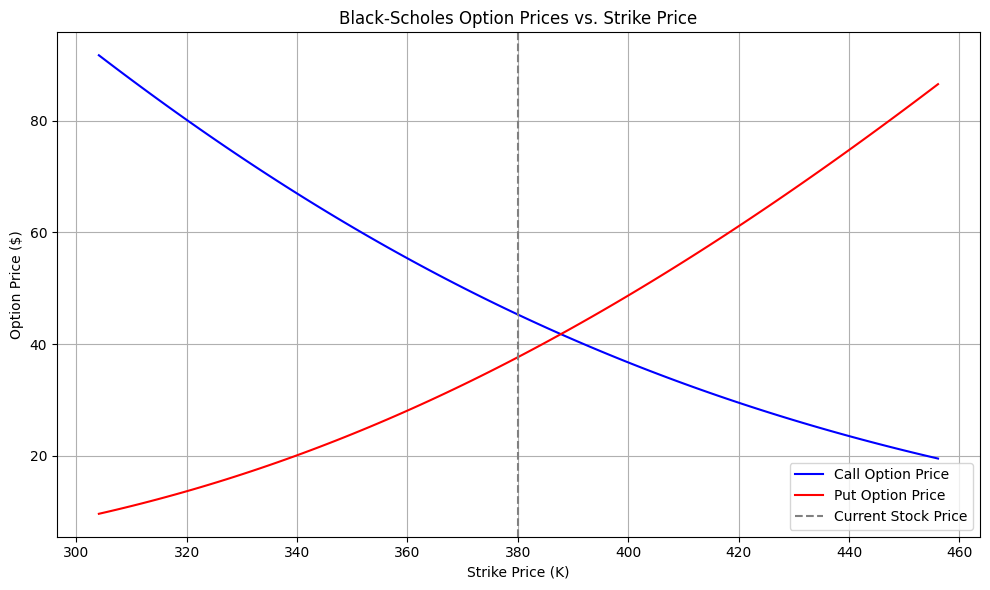

In [43]:
import matplotlib.pyplot as plt

strike_prices = np.linspace(current_stock_price * 0.8, current_stock_price * 1.2, 100)
call_prices_strike = [black_scholes_call(current_stock_price, K, time_to_expiration, risk_free_rate, volatility) for K in strike_prices]
put_prices_strike = [black_scholes_put(current_stock_price, K, time_to_expiration, risk_free_rate, volatility) for K in strike_prices]

plt.figure(figsize=(10, 6))
plt.plot(strike_prices, call_prices_strike, label='Call Option Price', color='blue')
plt.plot(strike_prices, put_prices_strike, label='Put Option Price', color='red')
plt.axvline(current_stock_price, color='gray', linestyle='--', label='Current Stock Price')
plt.title('Black-Scholes Option Prices vs. Strike Price')
plt.xlabel('Strike Price (K)')
plt.ylabel('Option Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

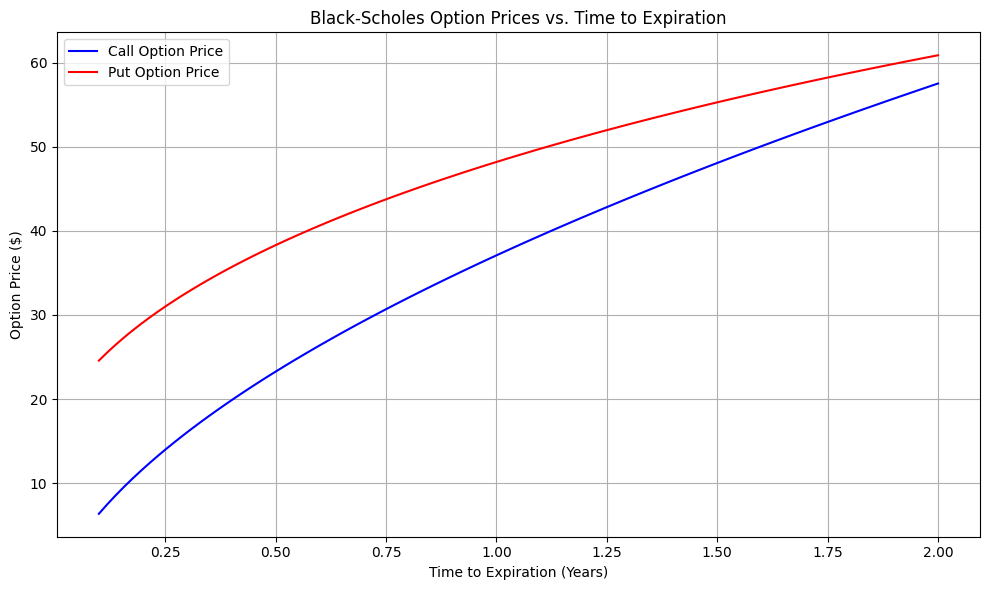

In [44]:
time_to_expirations = np.linspace(0.1, 2.0, 100)
call_prices_tte = [black_scholes_call(current_stock_price, strike_price, T_val, risk_free_rate, volatility) for T_val in time_to_expirations]
put_prices_tte = [black_scholes_put(current_stock_price, strike_price, T_val, risk_free_rate, volatility) for T_val in time_to_expirations]

plt.figure(figsize=(10, 6))
plt.plot(time_to_expirations, call_prices_tte, label='Call Option Price', color='blue')
plt.plot(time_to_expirations, put_prices_tte, label='Put Option Price', color='red')
plt.title('Black-Scholes Option Prices vs. Time to Expiration')
plt.xlabel('Time to Expiration (Years)')
plt.ylabel('Option Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

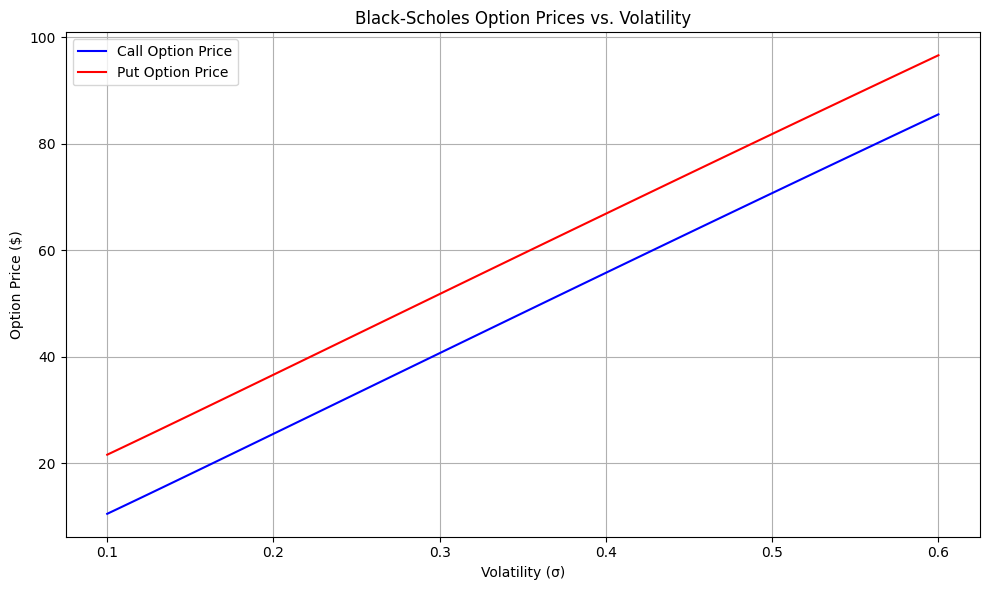

In [45]:
volatilities = np.linspace(0.1, 0.6, 100)
call_prices_vol = [black_scholes_call(current_stock_price, strike_price, time_to_expiration, risk_free_rate, sig) for sig in volatilities]
put_prices_vol = [black_scholes_put(current_stock_price, strike_price, time_to_expiration, risk_free_rate, sig) for sig in volatilities]

plt.figure(figsize=(10, 6))
plt.plot(volatilities, call_prices_vol, label='Call Option Price', color='blue')
plt.plot(volatilities, put_prices_vol, label='Put Option Price', color='red')
plt.title('Black-Scholes Option Prices vs. Volatility')
plt.xlabel('Volatility (σ)')
plt.ylabel('Option Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()